In [2]:
%pip install geopandas folium

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 113 kB 8.0 MB/s eta 0:00:01
     |████████████████████████████████| 134 kB 29.0 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 25.6 MB/s eta 0:00:01
     |████████████████████████████████| 94 kB 15.3 MB/s eta 0:00:01
     |████████████████████████████████| 299 kB 38.4 MB/s eta 0:00:01
     |████████████████████████████████| 68 kB 26.3 MB/s eta 0:00:01
     |████████████████████████████████| 131 kB 98.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from energy_processor import load_combined_gdf, process_energy_csv

# Load the already-combined NYCHA+PLUTO CSV as a GeoDataFrame
combined_gdf = load_combined_gdf('../cleaned_data/combined_nychares_pluto.csv')

combined_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 93 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   development                        2961 non-null   object  
 1   tds_#                              2961 non-null   int64   
 2   building_#                         2961 non-null   object  
 3   stairhall#                         2961 non-null   int64   
 4   borough_nycha                      2961 non-null   object  
 5   house_#                            2961 non-null   object  
 6   street                             2961 non-null   object  
 7   address_nycha                      2961 non-null   object  
 8   city                               2961 non-null   object  
 9   state                              2961 non-null   object  
 10  zip_code                           2961 non-null   object  
 11  bin                                

In [4]:
print(f"Combined rows: {len(combined_gdf)}")
print(f"Columns: {combined_gdf.columns.tolist()}")

Combined rows: 2961
Columns: ['development', 'tds_#', 'building_#', 'stairhall#', 'borough_nycha', 'house_#', 'street', 'address_nycha', 'city', 'state', 'zip_code', 'bin', 'block', 'lot', 'BBL', 'census_tract_(2020)', 'neighborhood_tabulation_area_code', 'neighborhood_tabulation_area_name', 'community_district', 'city_council_district', 'state_assembly_district', 'state_senate_district', 'us_congressional_district', 'privately_managed', 'latitude_nycha', 'longitude_nycha', 'geometry', 'borough_pluto', 'tax_block', 'tax_lot', 'census_tract_2010', 'cb2010', 'council_district', 'postcode', 'policeprct', 'healtharea', 'address_pluto', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'ltdheight', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'resarea', 'garagearea', 'strgearea', 'otherarea', 'areasource', 'numbldgs', 'numfloors', 'unitsres', 'unitstotal', 'lotfront', 'lotdepth', 'bldgfront', 'bldgdepth', 'proxcode', 'irrlotcode', 'lottype', 'asses

Matplotlib is building the font cache; this may take a moment.


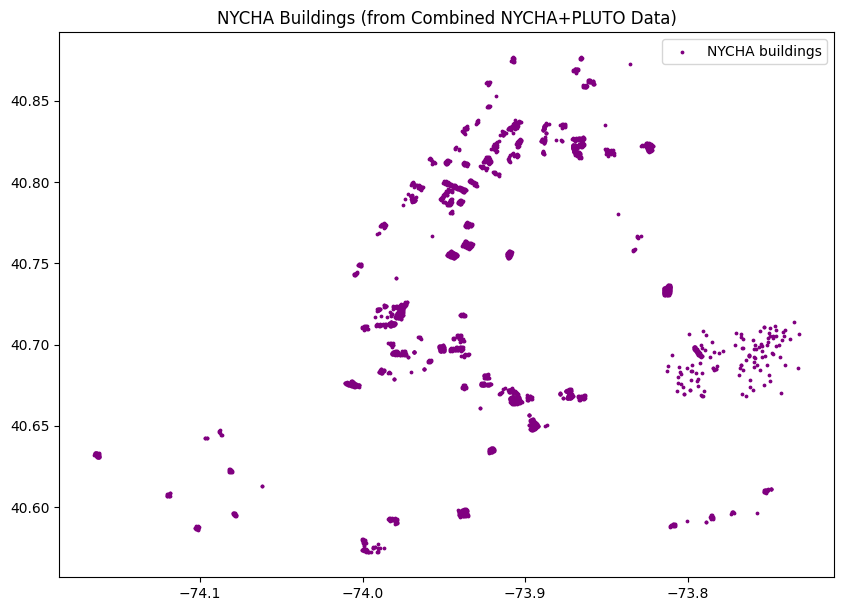

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
combined_gdf.plot(ax=ax, color='purple', markersize=3, label='NYCHA buildings')
ax.set_title('NYCHA Buildings (from Combined NYCHA+PLUTO Data)')
ax.legend()
plt.show()

In [6]:
# Check a sample of rows
combined_gdf[['BBL', 'bbl', 'development', 'landuse', 'yearbuilt']].sample(10)

,BBL,bbl,development,landuse,yearbuilt
1039,3079780001,3.079780e+09,GLENWOOD,3.0,1948.0
68,4004900101,4.004900e+09,ASTORIA,3.0,1950.0
682,1018360001,1.018360e+09,DOUGLASS I,3.0,1958.0
173,3081930001,3.081930e+09,BREUKELEN,2.0,1951.0
170,3081930001,3.081930e+09,BREUKELEN,2.0,1951.0
2338,3073870001,3.073870e+09,SHEEPSHEAD BAY,3.0,1950.0
2177,3005380001,3.005380e+09,RED HOOK WEST,3.0,1940.0
2382,2037250001,2.037250e+09,SOTOMAYOR HOUSES,3.0,1953.0
1141,2025270032,2.025270e+09,HIGHBRIDGE GARDENS,3.0,1953.0
1138,1010830015,1.010830e+09,HARBORVIEW TERRACE,3.0,1977.0


In [7]:
import folium
from folium.plugins import MarkerCluster

# Center map on NYC
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add NYCHA points as clustered markers
marker_cluster = MarkerCluster().add_to(m)

for _, row in combined_gdf.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"BBL: {row['BBL']}<br>Development: {row.get('development', 'N/A')}",
    ).add_to(marker_cluster)

m

/Users/jamie/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [8]:
# Process steam data with the reusable function
final_gdf, steam_cost_df_cleaned = process_energy_csv(
    csv_path='../raw_data/Steam_Consumption_And_Cost_(2010_–_Sep_2025)_20260314.csv',
    consumption_col='Consumption (Mlbs)',
    combined_gdf=combined_gdf,
)
print(f"Rows with missing consumption: {final_gdf['consumption_(mlbs)'].isna().sum()}")
print(final_gdf[['development', 'tds_#', 'consumption_(mlbs)']].head(10))

Rows with missing consumption: 2865
                   development tds_#  consumption_(mlbs)
0  1162-1176 WASHINGTON AVENUE   233                 NaN
1           1471 WATSON AVENUE   214                 NaN
2         154 WEST 84TH STREET   359                 NaN
3            303 VERNON AVENUE   156                 NaN
4              45 ALLEN STREET   265                 NaN
5         830 AMSTERDAM AVENUE   150                 NaN
6                        ADAMS   118                 NaN
7                        ADAMS   118                 NaN
8                        ADAMS   118                 NaN
9                        ADAMS   118                 NaN


In [9]:
steam_cost_df_cleaned.columns.tolist()

['development_name',
 'borough',
 'tds_#',
 'funding_source',
 'vendor_name',
 'revenue_month',
 'service_start_date',
 'service_end_date',
 '#_days',
 'meter_number',
 'current_charges',
 'consumption_(mlbs)']

In [10]:
# Generate top 10 developments by aggregate steam consumption

final_gdf.groupby('development')['consumption_(mlbs)'].sum().sort_values(ascending=False).head(10)

development
FULTON                                1.495318e+07
WSUR (BROWNSTONES)                    5.741154e+06
BARUCH                                5.085312e+06
GOMPERS                               1.998099e+06
SEWARD PARK EXTENSION                 5.492675e+05
STRAUS                                5.156666e+05
DE HOSTOS APARTMENTS                  2.502991e+05
AMSTERDAM ADDITION                    2.197030e+05
WSUR (SITE C) 589 AMSTERDAM AVENUE    1.771054e+05
WSUR (SITE B) 74 WEST 92ND STREET     1.680390e+05
Name: consumption_(mlbs), dtype: float64

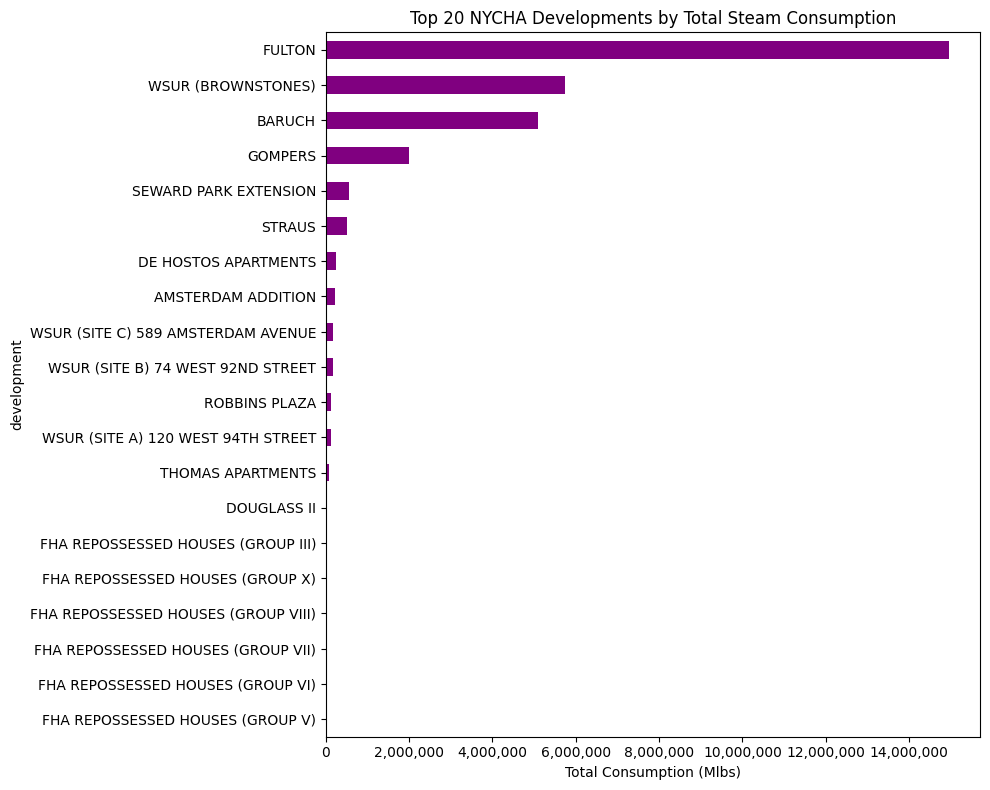

In [11]:
# Top 20 developments by total steam consumption

import matplotlib.pyplot as plt

top20_total = (
    final_gdf.groupby('development')['consumption_(mlbs)']
    .sum()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20_total.plot(kind='barh', ax=ax, color='purple')
ax.set_xlabel('Total Consumption (Mlbs)')
ax.set_title('Top 20 NYCHA Developments by Total Steam Consumption')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Top 20 developments by steam consumption per unit

final_gdf['consumption_(mlbs)'] = pd.to_numeric(final_gdf['consumption_(mlbs)'], errors='coerce')
# Top 20 developments by steam consumption per unit


final_gdf['consumption_(mlbs)'] = pd.to_numeric(final_gdf['consumption_(mlbs)'], errors='coerce')
final_gdf['unitsres'] = pd.to_numeric(final_gdf['unitsres'], errors='coerce')

final_gdf['consumption_per_unit'] = final_gdf['consumption_(mlbs)'] / final_gdf['unitsres']

top20_perunit = (
    final_gdf.dropna(subset=['development', 'consumption_per_unit'])
    .groupby('development')['consumption_per_unit']
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20_perunit.plot(kind='barh', ax=ax, color='mediumorchid')
ax.set_xlabel('Consumption per Residential Unit (Mlbs)')
ax.set_title('Top 20 NYCHA Developments by Steam Consumption Per Unit')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

final_gdf['consumption_per_unit'] = final_gdf['consumption_(mlbs)'] / final_gdf['unitsres']

top20_perunit = (
    final_gdf.dropna(subset=['development', 'consumption_per_unit'])
    .groupby('development')['consumption_per_unit']
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20_perunit.plot(kind='barh', ax=ax, color='mediumorchid')
ax.set_xlabel('Consumption per Residential Unit (Mlbs)')
ax.set_title('Top 20 NYCHA Developments by Steam Consumption Per Unit')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

In [ ]:
# Steam consumption vs building age

fig, ax = plt.subplots(figsize=(10, 6))

scatter_df = final_gdf.dropna(subset=['yearbuilt', 'consumption_(mlbs)'])
scatter_df = scatter_df[scatter_df['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df['yearbuilt'], scatter_df['consumption_(mlbs)'],
           alpha=0.5, color='purple', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Total Consumption (Mlbs)')
ax.set_title('Steam Consumption vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Steam consumption per unit vs building age

fig, ax = plt.subplots(figsize=(10, 6))

scatter_df2 = final_gdf.dropna(subset=['yearbuilt', 'consumption_per_unit'])
scatter_df2 = scatter_df2[scatter_df2['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df2['yearbuilt'], scatter_df2['consumption_per_unit'],
           alpha=0.5, color='mediumorchid', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Consumption (Mlbs) Per Unit')
ax.set_title('Steam Consumption Per Unit vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Steam costs per unit by borough

steam_cost_df_cleaned['revenue_month'] = pd.to_datetime(steam_cost_df_cleaned['revenue_month'])
steam_2024 = steam_cost_df_cleaned[
    steam_cost_df_cleaned['revenue_month'].dt.year == 2024
].copy()

# Clean and aggregate
steam_2024['current_charges'] = (
    steam_2024['current_charges']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
    .str.strip()
)
steam_2024['current_charges'] = pd.to_numeric(steam_2024['current_charges'], errors='coerce')

steam_agg_2024 = (
    steam_2024
    .groupby('tds_#')
    .agg({
        'consumption_(mlbs)': 'sum',
        'current_charges': 'sum',
        'borough': 'first'
    })
    .reset_index()
)

steam_agg_2024['tds_#'] = steam_agg_2024['tds_#'].astype(str).str.strip()
combined_gdf['tds_#'] = combined_gdf['tds_#'].astype(str).str.strip()

final_gdf_2024 = combined_gdf.merge(steam_agg_2024, on='tds_#', how='left')
final_gdf_2024['current_charges'] = pd.to_numeric(final_gdf_2024['current_charges'], errors='coerce')
final_gdf_2024['unitsres'] = pd.to_numeric(final_gdf_2024['unitsres'], errors='coerce')

# Calculate cost per unit
cost_per_unit_df = final_gdf_2024.dropna(subset=['current_charges', 'unitsres', 'borough']).copy()
cost_per_unit_df = cost_per_unit_df[cost_per_unit_df['unitsres'] > 0]
cost_per_unit_df['cost_per_unit'] = cost_per_unit_df['current_charges'] / cost_per_unit_df['unitsres']

# Build borough groups
borough_groups = {
    b: cost_per_unit_df[cost_per_unit_df['borough'] == b]['cost_per_unit'].dropna()
    for b in cost_per_unit_df['borough'].unique()
}
borough_groups = {k: v for k, v in borough_groups.items() if len(v) > 0}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(borough_groups.values(), labels=borough_groups.keys(), patch_artist=True,
           boxprops=dict(facecolor='purple', alpha=0.6))
ax.set_xlabel('Borough')
ax.set_ylabel('Steam Cost per Residential Unit ($)')
ax.set_title('Steam Cost per Unit by Borough — NYCHA (2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
final_gdf.to_csv('../cleaned_data/combined_steam_2024.csv', index=False)